In [1]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jnp.zeros(20) - 2.3

Array([-2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3,
       -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3, -2.3],      dtype=float32)

In [2]:
jnp.imag(3j)

Array(3., dtype=float32, weak_type=True)

In [7]:
t = jnp.zeros(20)

In [9]:
t

Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.], dtype=float32)

In [10]:
s = jax.random.normal(jax.random.key(0), (5,))

In [11]:
s

Array([ 1.6226422 ,  2.0252647 , -0.43359444, -0.07861735,  0.1760909 ],      dtype=float32)

In [12]:
from jax import lax
import jax
t = lax.dynamic_update_slice(
    t,
    s,
    (0,)
)

In [13]:
t

Array([ 1.6226422 ,  2.0252647 , -0.43359444, -0.07861735,  0.1760909 ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ],      dtype=float32)

### Testing complex grad of a function with real parameters

In [28]:
# So function that takes in (two inputs) and get differentials wrt each outputs

def complex_func_real_params(x, param):
    t = x * jnp.mean(param)
    return t * 1j 

In [34]:
t = jnp.array([3])

In [29]:
x = 4.0
def fixed_x(param):
    return complex_func_real_params(x, param)

In [33]:
batch_x = jax.vmap(complex_func_real_params, in_axes=(0, None))

In [ ]:
batch_x(jax.random.key(1), (3,1), dtype=float), 

In [30]:
t = jax.jacfwd(fixed_x)

In [31]:
t(jax.random.normal(jax.random.key(1), (3,), dtype=float))

Array([0.+1.3333334j, 0.+1.3333334j, 0.+1.3333334j], dtype=complex64)

In [6]:
import jax
t = jax.grad(func_mul, holomorphic=True)

In [8]:
t(3.0 + 1j)

Array(0.+1.j, dtype=complex64, weak_type=True)

### Other stuff

In [9]:
from ferminet.train import get_network

ModuleNotFoundError: No module named 'ferminet'

In [ ]:
from ferminet.configs.atom import get_config, adjust_nuclear_charge

cfg = get_config()
cfg.system.atom = 'H'
cfg = adjust_nuclear_charge(cfg)
key = jax.random.PRNGKey(seed=23)

network, params, signed_network, logabs_network, batch_network = get_network(cfg, key)

In [4]:
jnp.iscomplex(2+ 3j)

Array(True, dtype=bool, weak_type=True)

In [6]:
import jax
import jax.numpy as jnp

jax.lax.cond(True, lambda: 1, lambda: 2, None)


TypeError: <lambda>() takes 0 positional arguments but 1 was given

In [5]:
jnp.abs(2 + 3j)

Array(3.6055512, dtype=float32, weak_type=True)

In [18]:
jnp.angle(-2 + 0j, deg=False) 

Array(3.1415927, dtype=float32, weak_type=True)

In [46]:
freq = 4 / (2 * 3.14)

In [7]:
t = 3 - 1j

In [10]:
jnp.angle(jnp.exp(t), deg=True)

Array(-57.29578, dtype=float32, weak_type=True)

In [91]:
t - jnp.mean(t)

Array([0.9616577 , 0.96205324, 0.9624397 , ..., 0.67647725, 0.6792095 ,
       0.6819418 ], dtype=float32)

In [50]:
freq

0.6369426751592356

In [62]:
k = np.arange(0, 1000, 0.01)
t = [np.sin(4 * i) for i in k]

In [ ]:
t = [np.sin(0.04 * i) + np.cos(0.3 * i) for i in k]

In [82]:
t = jnp.array(t)

In [97]:
0.26 *  (2 * 3.14)

1.6328

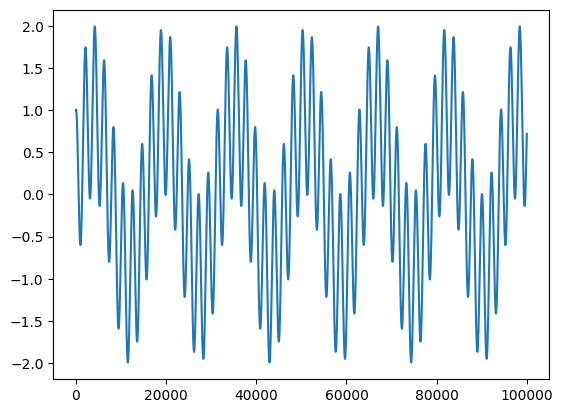

In [92]:
plt.plot(t)

In [87]:

def dominant_frequencies(x, dt, k=3, use_radians=False):
    N = len(x)

    # FFT
    X = jnp.fft.fft(x)
    freqs = jnp.fft.fftfreq(N, dt)      # Hz

    # Only positive frequencies (ignore DC separately)
    pos = freqs > 0
    freqs = freqs[pos]
    amps = jnp.abs(X[pos])

    # Remove DC-like offset if small f=0 is present (optional)
    # But since pos>0, we already skipped f=0

    # Sort by amplitude
    idx = jnp.argsort(amps)[::-1]       # descending
    top_idx = idx[:k]

    # Return frequencies + amplitudes
    if use_radians:
        return 2*np.pi*freqs[top_idx], amps[top_idx]
    else:
        return freqs[top_idx], amps[top_idx]


In [88]:
freqs, amps = dominant_frequencies(t, 0.01, k=10, use_radians=True)

In [86]:
freqs

Array([0.30159292, 0.03769911, 0.0439823 , 0.29530972, 0.03141593,
       0.30787608, 0.05026549, 0.02513274, 0.28902653, 0.05654867],      dtype=float32)

In [80]:
import matplotlib.pyplot as plt

def plot_top_frequencies_bar(freqs, amps, use_radians=True):
    # Sort for nicer display
    sort_idx = np.argsort(freqs)
    freqs = freqs[sort_idx]
    amps  = amps[sort_idx]

    plt.figure(figsize=(6,4))
    plt.bar(freqs, amps, width=0.1 * np.max(freqs))  # width auto-adjusted

    if use_radians:
        plt.xlabel("Frequency (rad/s)")
    else:
        plt.xlabel("Frequency (Hz)")

    plt.ylabel("Amplitude")
    plt.title("Top Dominant Frequencies")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


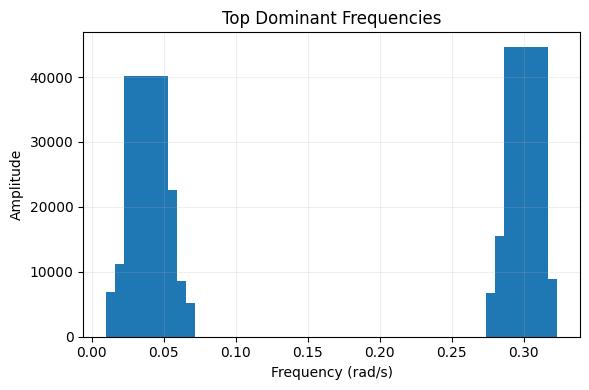

In [81]:
plot_top_frequencies_bar(freqs, amps)

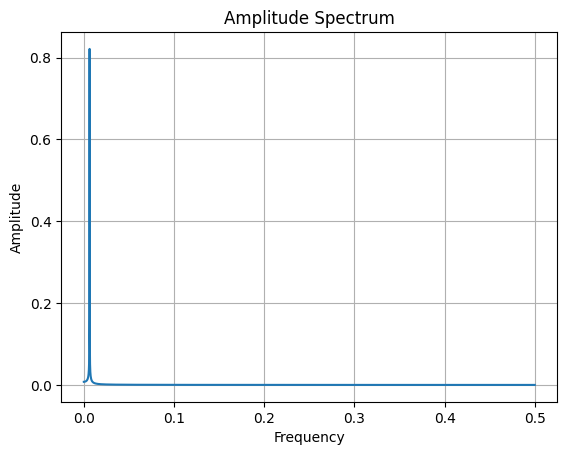

In [54]:
N = len(t)            # number of samples
dt = 0.01    # time step (example)
fs = 1/dt             # sampling rate


# Fourier transform
X = np.fft.fft(t)

# Frequencies corresponding to FFT bins
freqs = np.fft.fftfreq(N)
# Amplitude spectrum (one-sided for real signals)
amps = 2.0 / N * np.abs(X[:N//2])
freqs_pos = freqs[:N//2]

# Plot
plt.plot(freqs_pos, amps)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.title("Amplitude Spectrum")
plt.grid(True)
plt.show()

In [52]:
freqs_pos

array([0.000e+00, 1.000e-04, 2.000e-04, ..., 4.997e-01, 4.998e-01,
       4.999e-01], shape=(5000,))

In [44]:
freqs

[np.float64(0.0),
 np.float64(0.0006280000000000001),
 np.float64(0.0012560000000000002),
 np.float64(0.0018840000000000003),
 np.float64(0.0025120000000000003),
 np.float64(0.00314),
 np.float64(0.0037680000000000005),
 np.float64(0.004396),
 np.float64(0.005024000000000001),
 np.float64(0.005652000000000001),
 np.float64(0.00628),
 np.float64(0.006908000000000001),
 np.float64(0.007536000000000001),
 np.float64(0.008164000000000001),
 np.float64(0.008792),
 np.float64(0.009420000000000001),
 np.float64(0.010048000000000001),
 np.float64(0.010676000000000001),
 np.float64(0.011304000000000002),
 np.float64(0.011932),
 np.float64(0.01256),
 np.float64(0.013188000000000002),
 np.float64(0.013816000000000002),
 np.float64(0.014444),
 np.float64(0.015072000000000002),
 np.float64(0.015700000000000002),
 np.float64(0.016328000000000002),
 np.float64(0.016956000000000002),
 np.float64(0.017584),
 np.float64(0.018212000000000002),
 np.float64(0.018840000000000003),
 np.float64(0.019468000000

In [4]:
t = np.random.rand(4,4)

In [5]:
s = jnp.array(t)

In [7]:
s = s * 1j

In [8]:
s

Array([[0.+0.6350676j , 0.+0.8228788j , 0.+0.66029906j, 0.+0.4617141j ],
       [0.+0.52933705j, 0.+0.5818091j , 0.+0.7563156j , 0.+0.6481629j ],
       [0.+0.04283859j, 0.+0.5831088j , 0.+0.08777001j, 0.+0.04664368j],
       [0.+0.4633506j , 0.+0.8435559j , 0.+0.26074445j, 0.+0.37070656j]],      dtype=complex64)

In [11]:
jnp.linalg.eigvalsh(s)

Array([-0.3793741 , -0.03790221,  0.03790225,  0.37937403], dtype=float32)

In [1]:
import math

def E(t, w=0.6):
    return math.sin(w * t)


In [2]:
import numpy as np

t = np.arange(0, 100, 0.01)

In [3]:
E = [E(i) for i in t]

In [4]:
E

[0.0,
 0.0059999640000648,
 0.011999712002073594,
 0.017999028015746276,
 0.02399769606635429,
 0.02999550020249566,
 0.03599222450386925,
 0.04198765308904786,
 0.047981570123249925,
 0.05397375982610955,
 0.059964006479444595,
 0.06595209443502249,
 0.07193780812232353,
 0.07792093205630146,
 0.08390125084514082,
 0.08987854919801104,
 0.09585261193281704,
 0.10182322398394551,
 0.10779017041000746,
 0.11375323640157596,
 0.11971220728891936,
 0.12566686854972925,
 0.13161700581684335,
 0.1375624048859627,
 0.14350285172336283,
 0.14943813247359922,
 0.15536803346720587,
 0.16129234122838743,
 0.16721084248270432,
 0.17312332416475054,
 0.17902957342582418,
 0.18492937764158965,
 0.19082252441973235,
 0.19670880160760476,
 0.20258799729986385,
 0.20845989984609958,
 0.2143242978584545,
 0.22018098021923352,
 0.22602973608850413,
 0.23187035491168678,
 0.23770262642713458,
 0.24352634067370285,
 0.24934128799830768,
 0.2551472590634734,
 0.2609440448548687,
 0.26673143668883115,
 0.27

In [5]:
import matplotlib.pyplot as plt

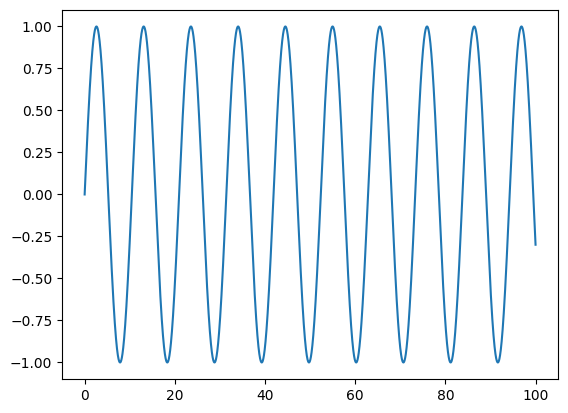

In [6]:
plt.plot(t, E)

In [1]:
import numpy as np

In [19]:
t = np.random.rand(4,4)

In [17]:
np.linalg.inv(t)

array([[ 0.68742719,  1.83206247, -3.021531  ,  0.36315402],
       [-1.38926932,  0.31083167,  2.43913048, -1.80981517],
       [ 1.14283772, -1.23676117,  1.54553455, -0.36780684],
       [-0.57570893,  0.81237598, -1.7614163 ,  2.02526818]])

In [23]:
np.linalg.eig(t)

EigResult(eigenvalues=array([ 2.002723  , -0.2873123 , -0.02510386,  0.20390102]), eigenvectors=array([[ 0.31282891, -0.64562727, -0.90049359,  0.77381983],
       [ 0.49192621,  0.43666109,  0.15121386,  0.13918032],
       [ 0.40531825,  0.35041864,  0.40388965, -0.61343634],
       [ 0.70417597, -0.51932581, -0.05584633,  0.07434756]]))

In [24]:
eigs = np.linalg.eig(t)

In [27]:
eigs[0]

array([ 2.002723  , -0.2873123 , -0.02510386,  0.20390102])

In [29]:
max(eigs[0]) ** 2

np.float64(4.010899409862333)

In [13]:
1e-4/t

array([0.0011363 , 0.00013231, 0.00040808, 0.00062184, 0.00021864,
       0.00012667, 0.00011838, 0.00016812, 0.00016547, 0.00055833,
       0.00021276, 0.00085043, 0.00022208, 0.00029139, 0.0001836 ,
       0.00036243, 0.00392488, 0.00022913, 0.0003918 , 0.00027033,
       0.00011111, 0.00011082, 0.00014955, 0.00070064, 0.00035484,
       0.00020408, 0.00054824, 0.00038027, 0.00031224, 0.0001346 ,
       0.00016984, 0.00010858, 0.0018912 , 0.0003883 , 0.00019591,
       0.00023057, 0.00023211, 0.00022844, 0.00025406, 0.00025145,
       0.00046556, 0.00012722, 0.00052154, 0.00012999, 0.00015464,
       0.00013825, 0.00011067, 0.00039348, 0.00013921, 0.00037818,
       0.00013108, 0.0004238 , 0.00011461, 0.00021423, 0.00047261,
       0.00023615, 0.00013144, 0.000327  , 0.00096697, 0.00010815,
       0.0003446 , 0.00024229, 0.00011699, 0.03340299, 0.00020212,
       0.00025862, 0.00010725, 0.00010036, 0.00071896, 0.00050912,
       0.00010602, 0.00010753, 0.00174655, 0.00026512, 0.00028